In [1]:
import vald_api_utilities as vau
import vald_forceDeck_api as vfda

%load_ext autoreload
%autoreload 2

# Initialize organizational parameters
Vald should provide a "Client ID", "Client Secret", and a "Tenant ID". The "Tenant ID" is some what interchangable with the "Team ID" and can be acquired through the External Tenant API call.

In [2]:
# Read credentials using vald_api_utilities function
creds = vau.read_credentials()

client_id = creds['client_id']
client_secret = creds['client_secret']
tenantId = creds['tenant_id']

print(f"Client ID: {client_id}")
print(f"Client Secret: {client_secret}")
print(f"Tenant ID: {tenantId}")

Client ID: 
Client Secret: 
Tenant ID: 


### Initialize Vald API Class Function  
The class functions as a wrapper for the External Tenant and External Profile API calls.

In [10]:
vald = vau.vald_api(client_id,client_secret,tenant_id=tenantId)

### Step 1 - Get Token
"get_token()" should always be your first api call as this gives you a temparoray access key to be used for all future calls

In [11]:
vald.get_token()

#### OPTIONAL - "get_all_tenants()" or "get_tenant_info()"
Use "get_all_tenants()" to return a dictionary with all tenants.
Use "get_tenant_info()" to return a dictionary with additional inforamtion about specific tenant.

In [48]:
vald.get_all_tenants()
#vald.tenants

In [49]:
# If not initializing class function with "tenant ID" then enter 
# tenant_id here, using commented example.
# vald.get_tenant_info(tenant_id=vald.tenants[0]['id'])

# If initialized class function with "Tenant ID" then use the following.
vald.get_tenant_info()
#vald.tenant_info

### Step 2 - Get information on the categories and groups
Using the specified "Tenant ID", get information on the categories and groups for the "Tenant ID".

In [37]:
# Generated dataframe containing ID and name of each category
vald.get_tenant_categories()
vald.categories_df

,id,syncId,name
0,306f33af-2939-480b-bbd7-2ce643c888f0,None,Uncategorised
1,3a32a047-1292-49f1-a8aa-8f830ea58ac8,None,Position
2,1fdaf750-970a-4047-badc-945e6e6994cf,None,Team
3,2828d5d2-ce26-4297-b4c1-a16039889a86,None,Sport


In [38]:
# Generated dataframe of groups ID, name, and category ID. 
vald.get_tenant_groups()
vald.groups_df.head()

,id,name,categoryId,syncId
0,286167da-0a3c-4da9-9b09-316ba9f6e089,Acro and Tumbling,1fdaf750-970a-4047-badc-945e6e6994cf,None
1,61694101-179d-483f-a8c7-8c5632362760,Acro and Tumbling,2828d5d2-ce26-4297-b4c1-a16039889a86,None
2,3c50c472-b4cf-45fa-9850-6dc59b37ffaf,Archive,1fdaf750-970a-4047-badc-945e6e6994cf,None
3,20588edf-7394-489c-a502-1f0c10c25db8,Baseball,2828d5d2-ce26-4297-b4c1-a16039889a86,None
4,f26a6a9c-7232-4d01-a214-b3f8584ba293,Baseball,1fdaf750-970a-4047-badc-945e6e6994cf,None


### Step 3 - Get all profiles in a specific group.
Use "get_group_profiles()" to generate dataframe of all athlete profiles in a given group based on the category and group dataframe. It is important to generate both the group and category dateframes as both of these will used to identify the correct IDs.

In [39]:
# category_name is used to get the category ID which is used to get the correct group ID.
# This insures that when there are groups' with the same name in different categories, 
# the correct group ID is found.

# Replace 'Baseball' (group name) with desired value.
vald.get_group_profiles('Research',category_name='Team')
vald.profile_df.head()

,profileId,syncId,givenName,familyName,dateOfBirth,externalId,beingMergedWithProfileId,beingMergedWithProfileExpiryDateUtc
0,d40fe7d3-cdab-4107-87d9-0fafd0374f21,None,Research,5,2025-04-01T00:00:00,None,None,None
1,38c0d088-2386-47de-9ce0-3217df35d323,None,Research,9,2025-04-01T00:00:00,None,None,None
2,3c081f68-0c02-4448-9792-5765675776f2,None,Research,3,2025-04-01T00:00:00,None,None,None
3,1f7dcf33-c0ac-46a0-8862-5e0196e3f122,None,Research,2,2025-04-01T00:00:00,None,None,None
4,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,None,Research,10,2025-04-01T00:00:00,None,None,None


# Force Decks API Call
After gathering the tenant ID and profile IDs we can use this information to pull force decks results.

In [40]:
# Initialize Force Decks class function with tenant ID and header from Vald class function.
forceDecks = vfda.forceDecks_api(vald.tenant_id,vald.header)

### Step 1 - Get Test Info
Using "get_tests_info()", you must include a date from which you would like get all tests since. You can also include a profile ID to filter on.

In [43]:
date = '30/08/2024' # date must be in "dd/mm/yyyy" format
profileID = vald.profile_df.loc[4,'profileId'] # pull profile ID from Vald class funciton

forceDecks.get_tests_info(date,profile_id=profileID)

Request Completed.


In [44]:
forceDecks.tests_df.head()

,testId,tenantId,profileId,recordingId,modifiedDateUtc,recordedDateUtc,recordedDateOffset,recordedDateTimezone,analysedDateUtc,analysedDateOffset,analysedDateTimezone,testType,weight,extendedParameters,attributes
0,5e5e8787-3ff7-4701-baac-3e6f10017d71,61476d2d-917a-4b2e-b2f6-e43346d2cb66,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,543e2ed5-e08b-4599-8157-4738edbd09af,2025-07-14T21:08:35.392Z,2025-07-14T21:07:42.910045Z,-420,Pacific Standard Time,2025-07-14T21:08:04.76585Z,-420,Pacific Standard Time,CMJ,62.6,[],[]


### Step 2 - Get rep results from test
Using "get_test_results()", a test ID is used to pull the results for each rep within a denoted test. The resulting dataframe contains a row for each result from each rep.

In [45]:
testID = forceDecks.tests_df.loc[0,'testId']
forceDecks.get_test_results(testID)
forceDecks.results_df.head()

,resultId,value,time,limb,repeat,testId,rep,id,athleteId,hubAthleteId,...,startTime,endTime,lastModifiedUTC,resultID,result,description,name,unit,repeatable,asymmetry
0,655365,18.226000,18.226,Trial,0,5e5e8787-3ff7-4701-baac-3e6f10017d71,1,4b2adcf2-8d09-4f31-b8e8-ebb7f270a654,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,...,17.262,20.288,2025-07-14T21:08:35.392Z,655365,START_OF_MOVEMENT,Absolute time from the start of recording to s...,Start of Movement,Second,False,True
1,655366,19.176586,18.226,Trial,0,5e5e8787-3ff7-4701-baac-3e6f10017d71,1,4b2adcf2-8d09-4f31-b8e8-ebb7f270a654,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,...,17.262,20.288,2025-07-14T21:08:35.392Z,655366,START_OF_MOVEMENT_THRESHOLD,Threshold used for start of movement detection,Start of Movement Detection Threshold,Newton,False,False
2,655367,18.226000,18.226,Trial,0,5e5e8787-3ff7-4701-baac-3e6f10017d71,1,4b2adcf2-8d09-4f31-b8e8-ebb7f270a654,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,...,17.262,20.288,2025-07-14T21:08:35.392Z,655367,START_OF_INTEGRATION,"Start time point for impulse, velocity and dis...",Start of Integration,Second,False,False
3,655386,62.600000,0.000,Trial,0,5e5e8787-3ff7-4701-baac-3e6f10017d71,1,4b2adcf2-8d09-4f31-b8e8-ebb7f270a654,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,...,17.262,20.288,2025-07-14T21:08:35.392Z,655386,BODY_WEIGHT,Mass of the profile in kilograms,Bodyweight in Kilograms,Kilo,False,False
4,655387,62.600000,0.000,Trial,0,5e5e8787-3ff7-4701-baac-3e6f10017d71,1,4b2adcf2-8d09-4f31-b8e8-ebb7f270a654,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,d34ffec7-f1ec-44fb-8fa9-b832fdf4bf34,...,17.262,20.288,2025-07-14T21:08:35.392Z,655387,BODY_WEIGHT_LBS,Mass of the profile in pounds,Bodyweight in Pounds,Pound,False,False


### Step 3 - Get the force trace for a given test
Using "get_force_trace()" will return the force trace in a dataframe for a given test ID.

In [46]:
forceDecks.get_force_trace(testID)
forceDecks.raw_df.head()

,Time,Left,Right,test_id
0,0.000,3.448659,1.271045,5e5e8787-3ff7-4701-baac-3e6f10017d71
1,0.002,-0.551341,0.271045,5e5e8787-3ff7-4701-baac-3e6f10017d71
2,0.004,-1.551341,-0.728955,5e5e8787-3ff7-4701-baac-3e6f10017d71
3,0.006,-0.551341,0.271045,5e5e8787-3ff7-4701-baac-3e6f10017d71
4,0.008,-1.551341,-0.728955,5e5e8787-3ff7-4701-baac-3e6f10017d71


<Axes: title={'center': 'Force Trace'}, xlabel='Time'>

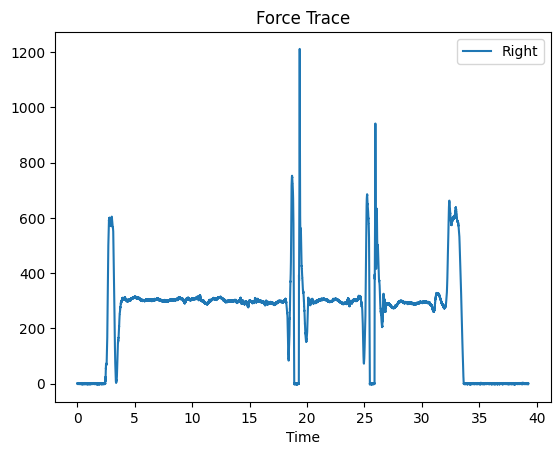

In [47]:
forceDecks.raw_df.plot(x='Time',y='Right',title='Force Trace')